# NB08: Temporal Stability of Groundwater Communities

**Goal**: Assess short-term stability of groundwater community composition over 9 days (Sep 9 vs Sep 18, 2024) at 5 SSO wells.

**Key questions**:
1. Are spatial patterns (which wells are similar) stable over 9 days?
2. Is within-well temporal variation smaller than between-well spatial variation? (If so, spatial patterns are robust)
3. Do filter size fractions (F01=0.1μm vs F8=8μm) capture different communities?
4. Does depth (SZ1 vs SZ2) matter more than date?

**Data structure**: 5 wells × 2 dates × 2 depths × 2 filter sizes = 40 samples

**Note**: Sediment was collected once per well (Feb-Mar 2023) — no within-well temporal replication for sediment. Cross-material temporal comparison (sed 2023 vs GW 2024) confounds material type with time.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import braycurtis, squareform, pdist
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIG = Path('../figures')

gw = pd.read_parquet(DATA / 'sso_groundwater_asv.parquet')

# Parse sample structure: well, date, depth zone, filter size
gw['well'] = gw['location']
gw['sz'] = gw['sample_id'].str.extract(r'(SZ\d)')
gw['filter'] = gw['sample_id'].str.extract(r'(F\d+)')

print(f"GW samples: {gw['sample_id'].nunique()}")
print(f"Wells: {sorted(gw['well'].unique())}")
print(f"Dates: {sorted(gw['date'].unique())}")
print(f"Depth zones: {sorted(gw['sz'].dropna().unique())}")
print(f"Filter sizes: {sorted(gw['filter'].dropna().unique())}")
print(f"\nSample structure:")
print(gw.groupby(['well', 'date', 'sz', 'filter'])['sample_id'].first().unstack(['date', 'sz']).to_string())

GW samples: 40
Wells: ['SSO-L7', 'SSO-L9', 'SSO-M4', 'SSO-M6', 'SSO-U2']
Dates: ['2024-09-09', '2024-09-18']
Depth zones: ['SZ1', 'SZ2']
Filter sizes: ['F01', 'F8']

Sample structure:
date                    2024-09-09                                2024-09-18                     
sz                             SZ1                  SZ2                  SZ1                  SZ2
well   filter                                                                                    
SSO-L7 F01     L7-SZ1-20240909-F01  L7-SZ2-20240909-F01  L7-SZ1-20240918-F01  L7-SZ2-20240918-F01
       F8       L7-SZ1-20240909-F8   L7-SZ2-20240909-F8   L7-SZ1-20240918-F8   L7-SZ2-20240918-F8
SSO-L9 F01     L9-SZ1-20240909-F01  L9-SZ2-20240909-F01  L9-SZ1-20240918-F01  L9-SZ2-20240918-F01
       F8       L9-SZ1-20240909-F8   L9-SZ2-20240909-F8   L9-SZ1-20240918-F8   L9-SZ2-20240918-F8
SSO-M4 F01     M4-SZ1-20240909-F01  M4-SZ2-20240909-F01  M4-SZ1-20240918-F01  M4-SZ2-20240918-F01
       F8       M4-SZ1-20240909-

## 1. PERMANOVA: Variance Partitioning (Well × Date × Depth × Filter)

Partition community variance among the four factors to determine their relative importance.

In [2]:
# Build sample-level community matrix for GW
gw_matrix = gw.pivot_table(index='sample_id', columns='asv_id', values='abundance', 
                           fill_value=0, aggfunc='sum')
gw_rel = gw_matrix.div(gw_matrix.sum(axis=1), axis=0)

# Compute BC dissimilarity
bc_condensed = pdist(gw_rel.values, metric='braycurtis')
bc_sq = squareform(bc_condensed)

# Sample metadata
gw_meta = gw.groupby('sample_id').first()[['well', 'date', 'sz', 'filter', 'depth_meter']].copy()
gw_meta = gw_meta.loc[gw_rel.index]

# One-way PERMANOVA for each factor
def permanova_f(dm_sq, grouping, n_perm=9999):
    groups = grouping.values
    unique_groups = np.unique(groups[~pd.isna(groups)])
    N = len(groups)
    a = len(unique_groups)
    dm2 = dm_sq ** 2
    ss_total = dm2.sum() / (2 * N)
    ss_within = 0
    for g in unique_groups:
        idx = np.where(groups == g)[0]
        ni = len(idx)
        if ni > 1:
            ss_within += dm2[np.ix_(idx, idx)].sum() / (2 * ni)
    ss_between = ss_total - ss_within
    f_obs = (ss_between / (a - 1)) / (ss_within / (N - a)) if (N - a) > 0 else 0
    r2 = ss_between / ss_total if ss_total > 0 else 0
    count_ge = 0
    for _ in range(n_perm):
        perm = np.random.permutation(N)
        groups_perm = groups[perm]
        ss_w_perm = 0
        for g in unique_groups:
            idx = np.where(groups_perm == g)[0]
            ni = len(idx)
            if ni > 1:
                ss_w_perm += dm2[np.ix_(idx, idx)].sum() / (2 * ni)
        ss_b_perm = ss_total - ss_w_perm
        f_perm = (ss_b_perm / (a - 1)) / (ss_w_perm / (N - a)) if (N - a) > 0 else 0
        if f_perm >= f_obs:
            count_ge += 1
    p_value = (count_ge + 1) / (n_perm + 1)
    return {'F': f_obs, 'R2': r2, 'p': p_value}

np.random.seed(42)
factors = {
    'well': gw_meta['well'],
    'date': gw_meta['date'],
    'depth (SZ)': gw_meta['sz'],
    'filter size': gw_meta['filter'],
}

print("PERMANOVA: GW Community Variance Partitioning (one-way each)")
print(f"{'Factor':<15} {'R²':>7} {'F':>8} {'p':>8}")
print("-" * 40)
for name, grouping in factors.items():
    result = permanova_f(bc_sq, grouping, n_perm=9999)
    sig = "***" if result['p'] < 0.001 else ("**" if result['p'] < 0.01 else ("*" if result['p'] < 0.05 else ""))
    print(f"{name:<15} {result['R2']*100:>6.1f}% {result['F']:>8.2f} {result['p']:>7.4f} {sig}")

PERMANOVA: GW Community Variance Partitioning (one-way each)
Factor               R²        F        p
----------------------------------------


well              49.9%     8.71  0.0001 ***


date               0.8%     0.31  0.9978 


depth (SZ)         2.5%     0.99  0.4202 


filter size       10.1%     4.26  0.0001 ***


## 2. Temporal Stability: Within-Well Dissimilarity Over 9 Days

For each well, compute BC between paired samples at the two dates (matching depth and filter). If spatial patterns are stable, within-well temporal variation should be small compared to between-well variation.

Temporal pairs (same well/depth/filter, 9 days apart): n=20
  Median BC = 0.351
  Range: 0.243 - 0.482

Spatial pairs (diff well, same date/depth/filter): n=80
  Median BC = 0.917

Spatial/temporal ratio: 2.6x
→ Spatial variation >> temporal variation: spatial patterns are temporally stable


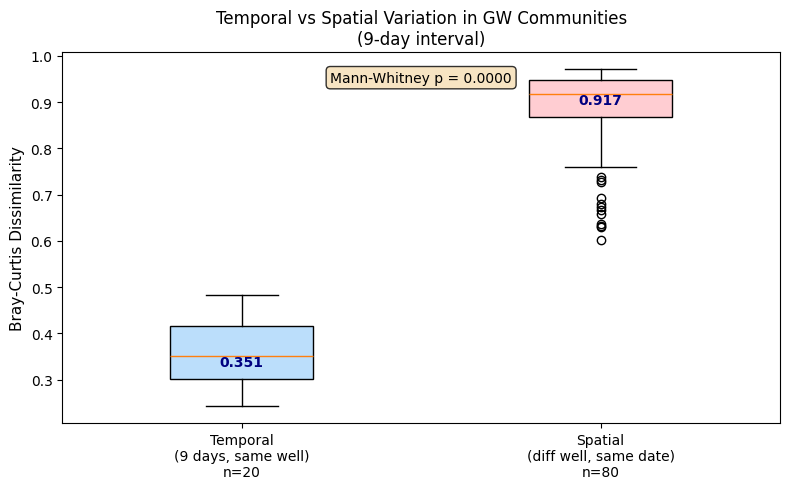

Saved: figures/temporal_vs_spatial_gw.png


In [3]:
# Paired temporal comparison: same well, same depth, same filter, different date
temporal_pairs = []
for well in sorted(gw_meta['well'].unique()):
    for sz in ['SZ1', 'SZ2']:
        for filt in ['F01', 'F8']:
            d1_mask = (gw_meta['well']==well) & (gw_meta['date']=='2024-09-09') & (gw_meta['sz']==sz) & (gw_meta['filter']==filt)
            d2_mask = (gw_meta['well']==well) & (gw_meta['date']=='2024-09-18') & (gw_meta['sz']==sz) & (gw_meta['filter']==filt)
            s1 = gw_meta[d1_mask].index
            s2 = gw_meta[d2_mask].index
            if len(s1) == 1 and len(s2) == 1:
                idx1 = list(gw_rel.index).index(s1[0])
                idx2 = list(gw_rel.index).index(s2[0])
                bc = bc_sq[idx1, idx2]
                temporal_pairs.append({
                    'well': well.replace('SSO-',''), 'sz': sz, 'filter': filt, 'bc_temporal': bc
                })

temp_df = pd.DataFrame(temporal_pairs)

# Between-well same-date pairs (spatial variation)
spatial_pairs = []
samples = gw_rel.index.tolist()
for i in range(len(samples)):
    for j in range(i+1, len(samples)):
        s1, s2 = samples[i], samples[j]
        if (gw_meta.loc[s1, 'well'] != gw_meta.loc[s2, 'well'] and
            gw_meta.loc[s1, 'date'] == gw_meta.loc[s2, 'date'] and
            gw_meta.loc[s1, 'sz'] == gw_meta.loc[s2, 'sz'] and
            gw_meta.loc[s1, 'filter'] == gw_meta.loc[s2, 'filter']):
            spatial_pairs.append(bc_sq[i, j])

print(f"Temporal pairs (same well/depth/filter, 9 days apart): n={len(temp_df)}")
print(f"  Median BC = {temp_df['bc_temporal'].median():.3f}")
print(f"  Range: {temp_df['bc_temporal'].min():.3f} - {temp_df['bc_temporal'].max():.3f}")
print(f"\nSpatial pairs (diff well, same date/depth/filter): n={len(spatial_pairs)}")
print(f"  Median BC = {np.median(spatial_pairs):.3f}")

ratio = np.median(spatial_pairs) / temp_df['bc_temporal'].median()
print(f"\nSpatial/temporal ratio: {ratio:.1f}x")
if ratio > 2:
    print("→ Spatial variation >> temporal variation: spatial patterns are temporally stable")

# Boxplot comparison
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([temp_df['bc_temporal'].values, spatial_pairs],
                labels=[f'Temporal\n(9 days, same well)\nn={len(temp_df)}',
                        f'Spatial\n(diff well, same date)\nn={len(spatial_pairs)}'],
                patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('#BBDEFB')
bp['boxes'][1].set_facecolor('#FFCDD2')

for i, data in enumerate([temp_df['bc_temporal'].values, spatial_pairs]):
    ax.text(i+1, np.median(data) - 0.02, f'{np.median(data):.3f}',
            ha='center', fontsize=10, fontweight='bold', color='navy')

ax.set_ylabel('Bray-Curtis Dissimilarity', fontsize=11)
ax.set_title('Temporal vs Spatial Variation in GW Communities\n(9-day interval)', fontsize=12)

stat, p = mannwhitneyu(temp_df['bc_temporal'], spatial_pairs, alternative='less')
ax.text(0.5, 0.95, f'Mann-Whitney p = {p:.4f}', transform=ax.transAxes,
        fontsize=10, ha='center', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(FIG / 'temporal_vs_spatial_gw.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/temporal_vs_spatial_gw.png")

## 3. Spatial Pattern Stability: Do Well Rankings Persist?

Test whether the ordering of well-to-well dissimilarities is consistent across the two dates. If spatial patterns are stable, the Mantel correlation between date-1 and date-2 distance matrices should be high.

Spatial pattern stability (Mantel between dates):
  Spearman rho = 0.867, p = 0.0012
  → Strong temporal stability: spatial patterns are nearly identical at 9-day interval


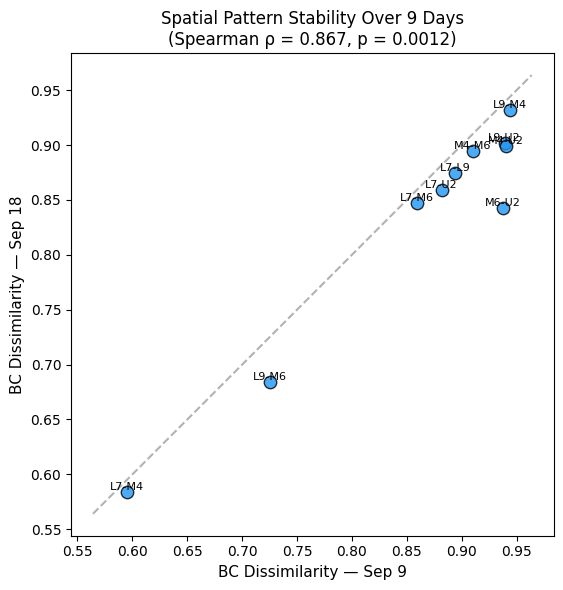

Saved: figures/spatial_stability_mantel.png


In [4]:
# Build well-aggregated matrices for each date separately
wells_gw = sorted(gw_meta['well'].unique())

def well_matrix_for_date(date_str):
    """Build well-aggregated relative abundance matrix for a single date."""
    mask = gw['date'] == date_str
    date_data = gw[mask]
    well_asv = (date_data.groupby(['location', 'asv_id'])['abundance'].sum()
                .reset_index()
                .pivot(index='location', columns='asv_id', values='abundance')
                .fillna(0))
    well_rel = well_asv.div(well_asv.sum(axis=1), axis=0)
    return well_rel

d1_rel = well_matrix_for_date('2024-09-09').loc[wells_gw]
d2_rel = well_matrix_for_date('2024-09-18').loc[wells_gw]

# Align columns
all_asvs = sorted(set(d1_rel.columns) | set(d2_rel.columns))
d1_rel = d1_rel.reindex(columns=all_asvs, fill_value=0)
d2_rel = d2_rel.reindex(columns=all_asvs, fill_value=0)

# BC matrices per date
bc_d1 = squareform(pdist(d1_rel.values, metric='braycurtis'))
bc_d2 = squareform(pdist(d2_rel.values, metric='braycurtis'))

# Mantel-style: correlate upper triangles
idx = np.triu_indices(5, k=1)
rho, p = spearmanr(bc_d1[idx], bc_d2[idx])
print(f"Spatial pattern stability (Mantel between dates):")
print(f"  Spearman rho = {rho:.3f}, p = {p:.4f}")
if rho > 0.7:
    print(f"  → Strong temporal stability: spatial patterns are nearly identical at 9-day interval")
elif rho > 0.4:
    print(f"  → Moderate stability: spatial patterns persist but with some temporal noise")
else:
    print(f"  → Weak stability: spatial patterns shift substantially over 9 days")

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 6))
well_pairs = []
for k in range(len(idx[0])):
    i, j = idx[0][k], idx[1][k]
    well_pairs.append(f"{wells_gw[i].replace('SSO-','')}-{wells_gw[j].replace('SSO-','')}")
    
ax.scatter(bc_d1[idx], bc_d2[idx], s=80, edgecolors='k', c='#2196F3', alpha=0.8)
for k, label in enumerate(well_pairs):
    ax.annotate(label, (bc_d1[idx][k], bc_d2[idx][k]), fontsize=8, ha='center', va='bottom')

# 1:1 line
lims = [min(bc_d1[idx].min(), bc_d2[idx].min()) - 0.02,
        max(bc_d1[idx].max(), bc_d2[idx].max()) + 0.02]
ax.plot(lims, lims, 'k--', alpha=0.3)

ax.set_xlabel('BC Dissimilarity — Sep 9', fontsize=11)
ax.set_ylabel('BC Dissimilarity — Sep 18', fontsize=11)
ax.set_title(f'Spatial Pattern Stability Over 9 Days\n(Spearman ρ = {rho:.3f}, p = {p:.4f})', fontsize=12)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG / 'spatial_stability_mantel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/spatial_stability_mantel.png")

## 4. Filter Size Effect: Free-Living vs Particle-Associated

The two filter fractions (F01 = 0.1 μm, F8 = 8 μm) capture different size classes:
- **F01**: Free-living bacteria and archaea (0.1-8 μm)
- **F8**: Particle-associated / aggregate-attached organisms (>8 μm aggregates)

Do these fractions show different communities or spatial patterns?

In [5]:
# Filter size comparison
# Paired: same well, date, depth, different filter
filter_pairs = []
for well in sorted(gw_meta['well'].unique()):
    for date in ['2024-09-09', '2024-09-18']:
        for sz in ['SZ1', 'SZ2']:
            f01_mask = (gw_meta['well']==well) & (gw_meta['date']==date) & (gw_meta['sz']==sz) & (gw_meta['filter']=='F01')
            f8_mask = (gw_meta['well']==well) & (gw_meta['date']==date) & (gw_meta['sz']==sz) & (gw_meta['filter']=='F8')
            s1 = gw_meta[f01_mask].index
            s2 = gw_meta[f8_mask].index
            if len(s1) == 1 and len(s2) == 1:
                idx1 = list(gw_rel.index).index(s1[0])
                idx2 = list(gw_rel.index).index(s2[0])
                bc = bc_sq[idx1, idx2]
                filter_pairs.append({'well': well.replace('SSO-',''), 'date': date, 
                                    'sz': sz, 'bc_filter': bc})

filt_df = pd.DataFrame(filter_pairs)
print(f"Filter size effect (F01 vs F8, same well/date/depth): n={len(filt_df)}")
print(f"  Median BC = {filt_df['bc_filter'].median():.3f}")
print(f"  Range: {filt_df['bc_filter'].min():.3f} - {filt_df['bc_filter'].max():.3f}")
print(f"\n  Compare to temporal (9 days): median BC = {temp_df['bc_temporal'].median():.3f}")
print(f"  Compare to spatial (diff well): median BC = {np.median(spatial_pairs):.3f}")

# Per-well filter effect
print(f"\nFilter effect by well:")
for well in sorted(filt_df['well'].unique()):
    wdata = filt_df[filt_df['well'] == well]['bc_filter']
    print(f"  {well}: median BC = {wdata.median():.3f} (n={len(wdata)})")

Filter size effect (F01 vs F8, same well/date/depth): n=20
  Median BC = 0.750
  Range: 0.484 - 0.830

  Compare to temporal (9 days): median BC = 0.351
  Compare to spatial (diff well): median BC = 0.917

Filter effect by well:
  L7: median BC = 0.733 (n=4)
  L9: median BC = 0.806 (n=4)
  M4: median BC = 0.750 (n=4)
  M6: median BC = 0.748 (n=4)
  U2: median BC = 0.629 (n=4)


## 5. Summary

In [6]:
print("=" * 60)
print("NB08 TEMPORAL STABILITY SUMMARY")
print("=" * 60)

print(f"\n1. VARIANCE PARTITIONING (GW, one-way PERMANOVA)")
for name, grouping in factors.items():
    result = permanova_f(bc_sq, grouping, n_perm=999)  # quick recompute
    print(f"   {name:<15} R²={result['R2']*100:.1f}%  p={result['p']:.3f}")

print(f"\n2. TEMPORAL STABILITY")
print(f"   Within-well temporal BC (9 days): median = {temp_df['bc_temporal'].median():.3f}")
print(f"   Between-well spatial BC:          median = {np.median(spatial_pairs):.3f}")
print(f"   Spatial/temporal ratio:            {np.median(spatial_pairs)/temp_df['bc_temporal'].median():.1f}x")

print(f"\n3. SPATIAL PATTERN STABILITY")
print(f"   Mantel (date1 vs date2 distance matrices): rho = {rho:.3f}, p = {p:.4f}")

print(f"\n4. FILTER SIZE EFFECT")
print(f"   F01 vs F8 BC: median = {filt_df['bc_filter'].median():.3f}")
print(f"   (Compare: temporal = {temp_df['bc_temporal'].median():.3f}, spatial = {np.median(spatial_pairs):.3f})")

print(f"\n5. VARIATION HIERARCHY")
variations = {
    'Filter (F01 vs F8)': filt_df['bc_filter'].median(),
    'Temporal (9 days)': temp_df['bc_temporal'].median(),
    'Spatial (diff well)': np.median(spatial_pairs),
}
for name, val in sorted(variations.items(), key=lambda x: x[1]):
    print(f"   {name:<30} median BC = {val:.3f}")

print(f"\nFiles saved:")
print(f"  figures/temporal_vs_spatial_gw.png")
print(f"  figures/spatial_stability_mantel.png")

NB08 TEMPORAL STABILITY SUMMARY

1. VARIANCE PARTITIONING (GW, one-way PERMANOVA)


   well            R²=49.9%  p=0.001
   date            R²=0.8%  p=0.998


   depth (SZ)      R²=2.5%  p=0.430
   filter size     R²=10.1%  p=0.001

2. TEMPORAL STABILITY
   Within-well temporal BC (9 days): median = 0.351
   Between-well spatial BC:          median = 0.917
   Spatial/temporal ratio:            2.6x

3. SPATIAL PATTERN STABILITY
   Mantel (date1 vs date2 distance matrices): rho = 0.867, p = 0.0012

4. FILTER SIZE EFFECT
   F01 vs F8 BC: median = 0.750
   (Compare: temporal = 0.351, spatial = 0.917)

5. VARIATION HIERARCHY
   Temporal (9 days)              median BC = 0.351
   Filter (F01 vs F8)             median BC = 0.750
   Spatial (diff well)            median BC = 0.917

Files saved:
  figures/temporal_vs_spatial_gw.png
  figures/spatial_stability_mantel.png
